# BAF 사기 탐지 - EDA
전처리된 train/valid parquet을 가지고 데이터를 직접 탐색합니다.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

# 기본 폰트(DejaVu Sans)는 한글을 지원하지 않아 그래프의 한글 라벨이 깨져 보인다.
# macOS 기본 한글 폰트로 바꿔서 "정상"/"사기" 같은 라벨이 제대로 보이게 한다.
plt.rcParams['font.family'] = 'AppleGothic'
plt.rcParams['axes.unicode_minus'] = False  # 한글 폰트 사용 시 마이너스(-) 기호가 깨지는 것 방지

train = pd.read_parquet('../data/processed/train.parquet')
valid = pd.read_parquet('../data/processed/valid.parquet')

# EDA는 month 0~6(학습+검증)만 사용한다. month 7(test)은 드리프트 실험 전까지 사용 금지.
df = pd.concat([train, valid], ignore_index=True)
print(df.shape)
df.head()

(903157, 31)


,fraud_bool,income,name_email_similarity,prev_address_months_count,current_address_months_count,customer_age,days_since_request,intended_balcon_amount,payment_type,zip_count_4w,velocity_6h,velocity_24h,velocity_4w,bank_branch_count_8w,date_of_birth_distinct_emails_4w,employment_status,credit_risk_score,email_is_free,housing_status,phone_home_valid,phone_mobile_valid,bank_months_count,has_other_cards,proposed_credit_limit,foreign_request,source,session_length_in_minutes,device_os,keep_alive_session,device_distinct_emails_8w,month
0,0,0.3,0.986506,NaN,25.0,40,0.006735,102.453711,AA,1059,13096.035018,7850.955007,6742.080561,5,5,CB,163,1,BC,0,1,9.0,0,1500.0,0,INTERNET,16.224843,linux,1,1.0,0
1,0,0.8,0.617426,NaN,89.0,20,0.010095,NaN,AD,1658,9223.283431,5745.251481,5941.664859,3,18,CA,154,1,BC,1,1,2.0,0,1500.0,0,INTERNET,3.363854,other,1,1.0,0
2,0,0.8,0.996707,9.0,14.0,40,0.012316,NaN,AB,1095,4471.472149,5471.988958,5992.555113,15,11,CA,89,1,BC,0,1,30.0,0,200.0,0,INTERNET,22.730559,windows,0,1.0,0
3,0,0.6,0.475100,11.0,14.0,30,0.006991,NaN,AB,3483,14431.993621,6755.344479,5970.336831,11,13,CA,90,1,BC,0,1,1.0,0,200.0,0,INTERNET,15.215816,linux,1,1.0,0
4,0,0.9,0.842307,NaN,29.0,40,5.742626,47.152498,AA,2339,7601.511579,5124.046930,5940.734212,1,6,CA,91,0,BC,1,1,26.0,0,200.0,0,INTERNET,3.743048,other,0,1.0,0


## 1. 클래스 불균형 확인

사기 비율이 실제로 얼마나 극단적인지 숫자와 그림으로 확인합니다.

사기 비율: 1.0630%  (사기 9601건 / 전체 903157건)


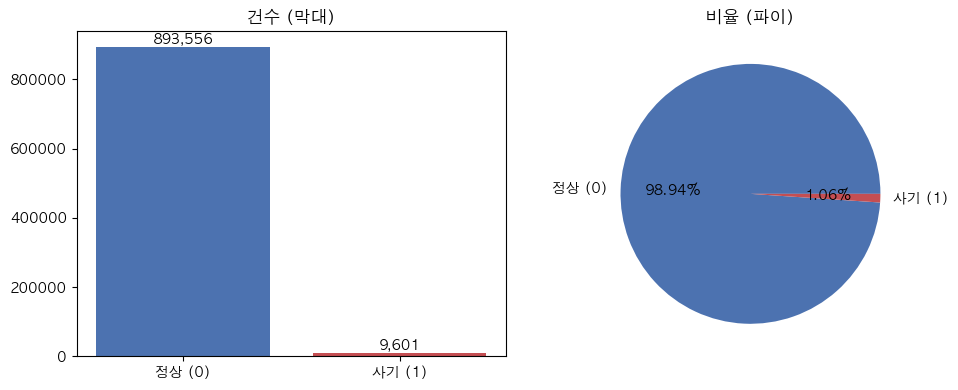

In [2]:
fraud_rate = df['fraud_bool'].mean()
print(f"사기 비율: {fraud_rate * 100:.4f}%  (사기 {df['fraud_bool'].sum()}건 / 전체 {len(df)}건)")

counts = df['fraud_bool'].value_counts().sort_index()
labels = ['정상 (0)', '사기 (1)']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(labels, counts.values, color=['#4C72B0', '#C44E52'])
axes[0].set_title('건수 (막대)')
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f'{v:,}', ha='center', va='bottom')

axes[1].pie(counts.values, labels=labels, autopct='%1.2f%%', colors=['#4C72B0', '#C44E52'])
axes[1].set_title('비율 (파이)')

plt.tight_layout()
plt.show()

## 2. 피처 분포 비교 (사기 vs 정상)

수치형 피처 몇 개를 골라서, 사기 그룹과 정상 그룹의 분포가 얼마나 다른지 히스토그램으로 비교합니다.
분포가 뚜렷하게 다르면, 그 피처가 모델이 사기를 구분하는 데 유용한 신호일 가능성이 높습니다.

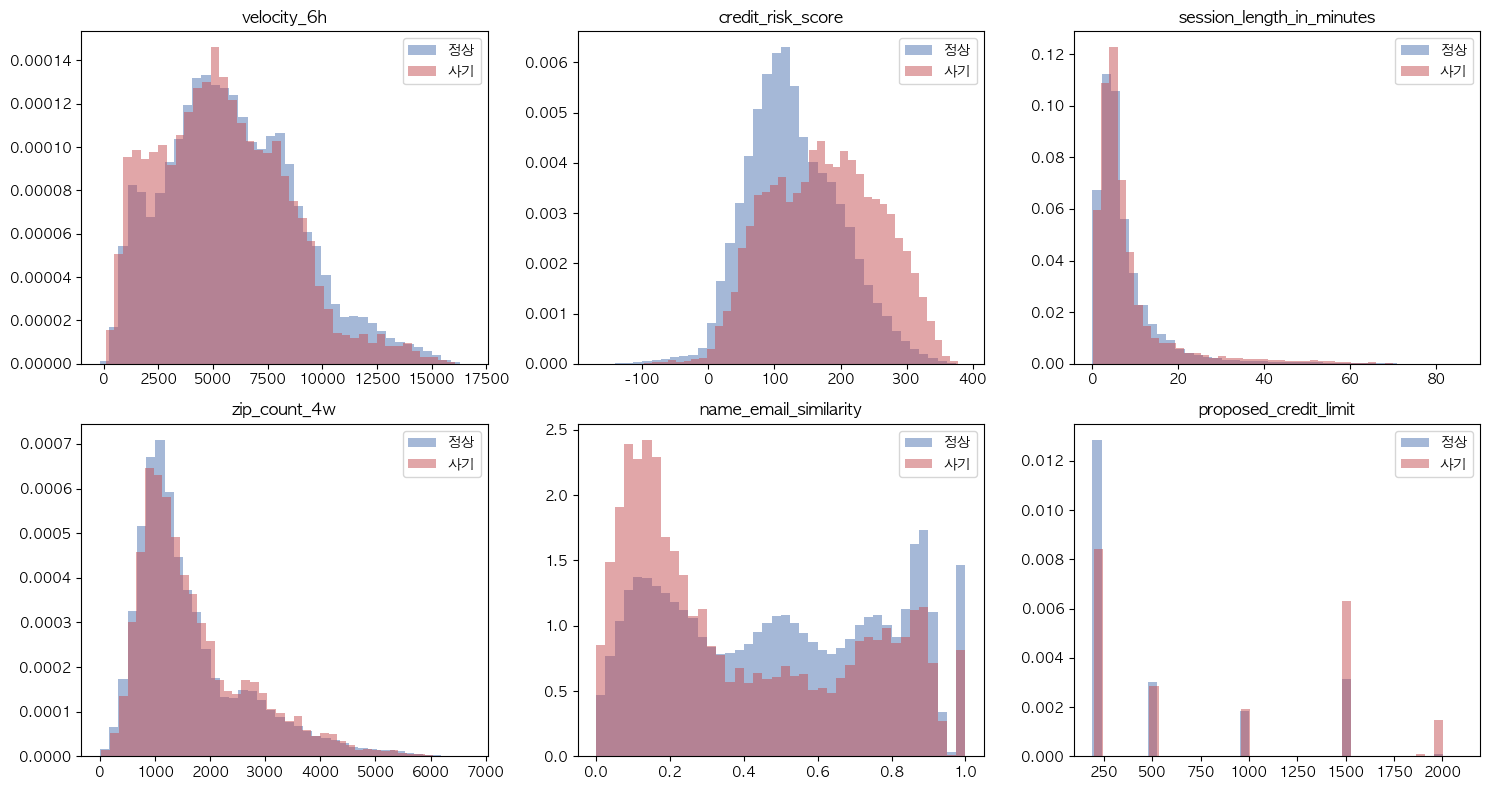

In [3]:
features_to_compare = [
    'velocity_6h',
    'credit_risk_score',
    'session_length_in_minutes',
    'zip_count_4w',
    'name_email_similarity',
    'proposed_credit_limit',
]

normal = df[df['fraud_bool'] == 0]
fraud = df[df['fraud_bool'] == 1]

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flatten(), features_to_compare):
    # 두 그룹 크기 차이가 커서(정상 98.9% vs 사기 1.1%), density=True로 비율 기준 비교
    ax.hist(normal[col].dropna(), bins=40, alpha=0.5, density=True, label='정상', color='#4C72B0')
    ax.hist(fraud[col].dropna(), bins=40, alpha=0.5, density=True, label='사기', color='#C44E52')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

## 3. 월별 사기율 변화

month 0~6 구간에서 사기 비율이 시간에 따라 어떻게 변하는지 봅니다.
(month 7은 3주차 드리프트 실험용이라 이 노트북에서도 사용하지 않습니다.)

과제 문서에서 미리 알려준 대로, valid(6월) 구간의 사기율이 train(0~5월)보다 높다는 걸
숫자표로만이 아니라 추이 그래프로 직접 확인합니다.

       fraud_rate  fraud_count  total_count  fraud_rate_pct
month                                                      
0        0.011326         1500       132440        1.132588
1        0.009387         1198       127620        0.938724
2        0.008746         1198       136979        0.874587
3        0.009222         1392       150936        0.922245
4        0.011371         1452       127691        1.137120
5        0.011825         1411       119323        1.182505
6        0.013405         1450       108168        1.340507


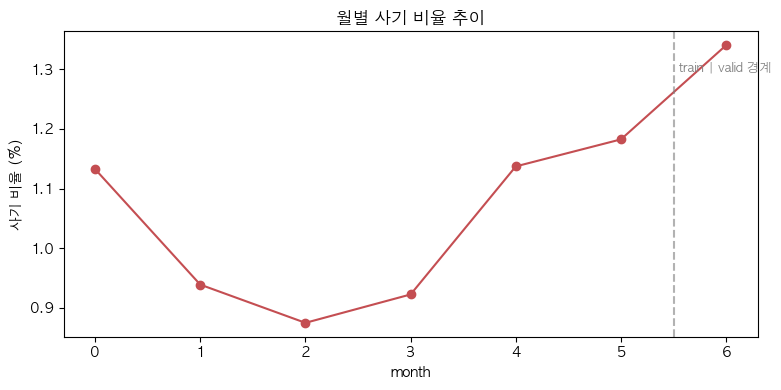

In [4]:
monthly = df.groupby('month')['fraud_bool'].agg(['mean', 'sum', 'count'])
monthly.columns = ['fraud_rate', 'fraud_count', 'total_count']
monthly['fraud_rate_pct'] = monthly['fraud_rate'] * 100
print(monthly)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(monthly.index, monthly['fraud_rate_pct'], marker='o', color='#C44E52')
ax.axvline(5.5, color='gray', linestyle='--', alpha=0.6)
ax.text(5.55, ax.get_ylim()[1] * 0.95, 'train | valid 경계', fontsize=9, color='gray')
ax.set_xlabel('month')
ax.set_ylabel('사기 비율 (%)')
ax.set_title('월별 사기 비율 추이')
plt.tight_layout()
plt.show()

## 4. 결측치 비율이 높은 컬럼과 사기 여부의 관계

전처리 단계에서 -1을 NaN으로 바꾼 컬럼들(`prev_address_months_count`, `bank_months_count` 등)은
결측 비율이 매우 높았습니다 (각각 71%, 25%). "정보가 없다"는 사실 자체가 사기와 관련이 있는지 확인합니다.

                              missing_pct  fraud_rate_when_missing  \
column                                                               
prev_address_months_count          71.938                    1.367   
bank_months_count                  25.023                    1.603   
current_address_months_count        0.379                    0.292   
session_length_in_minutes           0.201                    0.936   
device_distinct_emails_8w           0.038                    1.159   
intended_balcon_amount             73.471                    1.271   

                              fraud_rate_when_present  
column                                                 
prev_address_months_count                       0.284  
bank_months_count                               0.883  
current_address_months_count                    1.066  
session_length_in_minutes                       1.063  
device_distinct_emails_8w                       1.063  
intended_balcon_amount                         

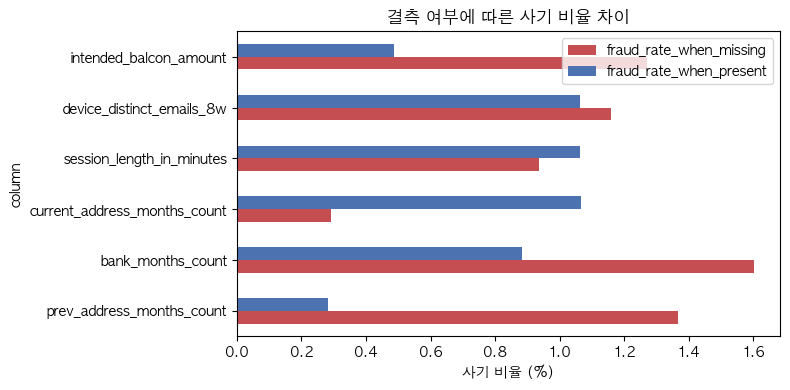

In [5]:
missing_cols = [
    'prev_address_months_count',
    'bank_months_count',
    'current_address_months_count',
    'session_length_in_minutes',
    'device_distinct_emails_8w',
    'intended_balcon_amount',
]

rows = []
for col in missing_cols:
    is_missing = df[col].isna()
    rows.append({
        'column': col,
        'missing_pct': is_missing.mean() * 100,
        'fraud_rate_when_missing': df.loc[is_missing, 'fraud_bool'].mean() * 100,
        'fraud_rate_when_present': df.loc[~is_missing, 'fraud_bool'].mean() * 100,
    })

missing_vs_fraud = pd.DataFrame(rows).set_index('column')
print(missing_vs_fraud.round(3))

missing_vs_fraud[['fraud_rate_when_missing', 'fraud_rate_when_present']].plot(
    kind='barh', figsize=(8, 4), color=['#C44E52', '#4C72B0']
)
plt.xlabel('사기 비율 (%)')
plt.title('결측 여부에 따른 사기 비율 차이')
plt.tight_layout()
plt.show()

## 5. 범주형 컬럼별 사기율

`payment_type`, `employment_status`, `housing_status`, `source`, `device_os` 각 카테고리별로
사기율에 차이가 있는지 확인합니다. 코드 자체의 의미는 익명이라 알 수 없지만,
특정 카테고리에서 사기율이 유난히 높다면 그 자체로 유용한 신호입니다.

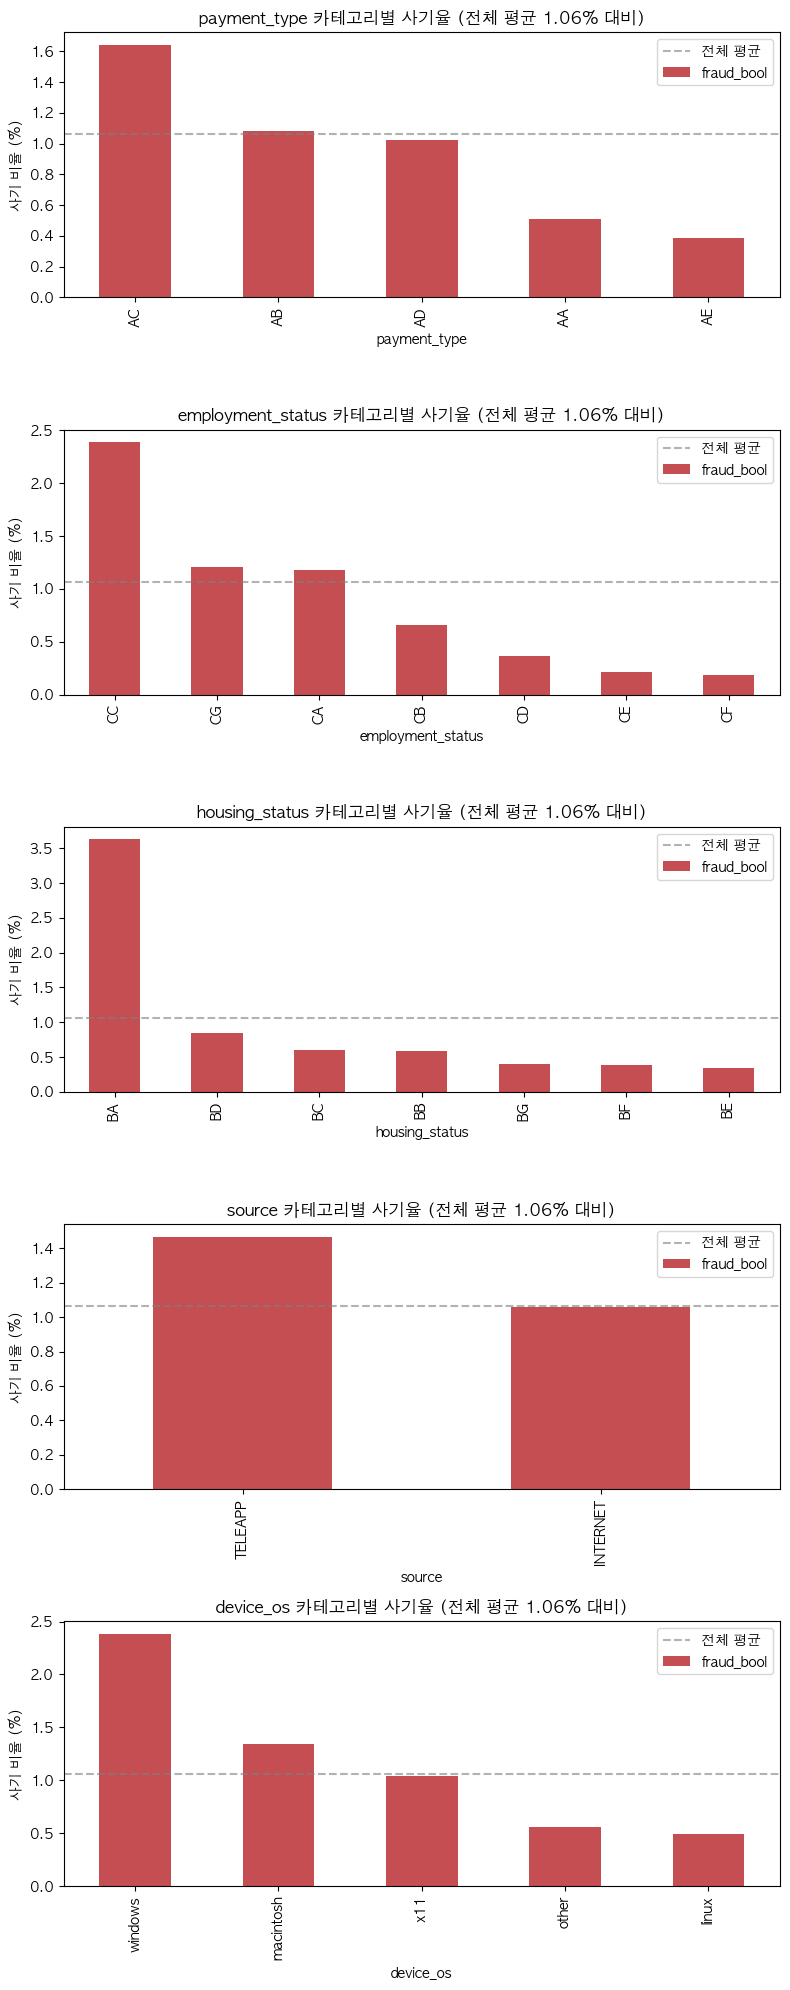

In [6]:
categorical_cols = ['payment_type', 'employment_status', 'housing_status', 'source', 'device_os']

fig, axes = plt.subplots(len(categorical_cols), 1, figsize=(8, 4 * len(categorical_cols)))
for ax, col in zip(axes, categorical_cols):
    rate = df.groupby(col, observed=True)['fraud_bool'].mean().sort_values(ascending=False) * 100
    n = df.groupby(col, observed=True)['fraud_bool'].size()
    rate.plot(kind='bar', ax=ax, color='#C44E52')
    ax.set_ylabel('사기 비율 (%)')
    ax.set_title(f'{col} 카테고리별 사기율 (전체 평균 {fraud_rate * 100:.2f}% 대비)')
    ax.axhline(fraud_rate * 100, color='gray', linestyle='--', alpha=0.6, label='전체 평균')
    ax.legend()

plt.tight_layout()
plt.show()

## 6. 어떤 피처가 사기와 가장 관련이 깊은가 (상관관계)

수치형 피처 하나하나가 `fraud_bool`(0 또는 1)과 얼마나 "같이 움직이는지"를 상관계수로 계산합니다.
상관계수는 -1~1 사이 값으로, 0에 가까우면 관련이 거의 없고, 1이나 -1에 가까울수록 관련이 강합니다.
(참고: 상관계수는 "직선적인 관계"만 잡아내므로, 관련이 있어도 상관계수가 낮게 나올 수 있습니다 — 참고용 지표입니다.)

credit_risk_score                   0.0682
proposed_credit_limit               0.0665
customer_age                        0.0631
keep_alive_session                 -0.0492
income                              0.0439
date_of_birth_distinct_emails_4w   -0.0429
device_distinct_emails_8w           0.0374
name_email_similarity              -0.0357
has_other_cards                    -0.0344
phone_home_valid                   -0.0331
current_address_months_count        0.0329
email_is_free                       0.0268
bank_months_count                   0.0210
prev_address_months_count           0.0186
foreign_request                     0.0165
intended_balcon_amount              0.0158
velocity_6h                        -0.0150
phone_mobile_valid                 -0.0141
bank_branch_count_8w               -0.0112
session_length_in_minutes           0.0092
month                               0.0088
velocity_24h                       -0.0087
velocity_4w                        -0.0071
zip_count_4

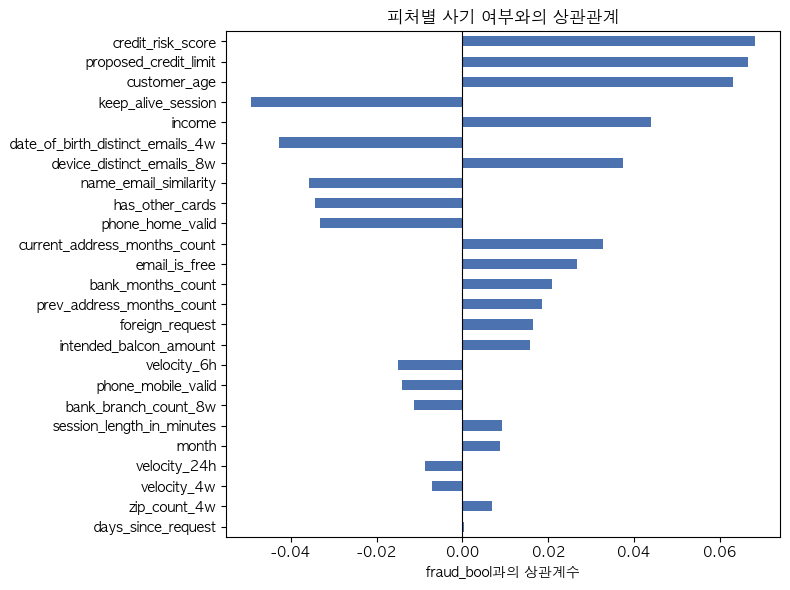

In [7]:
numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('fraud_bool')

# 각 수치형 피처와 fraud_bool 사이의 상관계수만 뽑아서 절댓값 기준 내림차순 정렬
corr_with_target = df[numeric_cols].corrwith(df['fraud_bool']).sort_values(key=abs, ascending=False)
print(corr_with_target.round(4))

fig, ax = plt.subplots(figsize=(8, 6))
corr_with_target.plot(kind='barh', ax=ax, color='#4C72B0')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('fraud_bool과의 상관계수')
ax.set_title('피처별 사기 여부와의 상관관계')
ax.invert_yaxis()  # 가장 관련 깊은 피처가 위로 오도록
plt.tight_layout()
plt.show()

## 7. 나이대별 사기율

`customer_age`를 그대로 쓰지 않고, 10살 단위 구간(20대, 30대...)으로 묶어서(binning)
나이대별 사기율 차이를 봅니다. 나이 하나하나보다 "구간"으로 보면 패턴이 더 잘 드러납니다.

           fraud_rate_pct   count
age_group                        
10대              0.337819   18057
20대              0.466571  224832
30대              0.782599  279070
40대              1.157210  210852
50대              1.951343  130628
60대              3.154731   32269
70대+             4.013015    7376


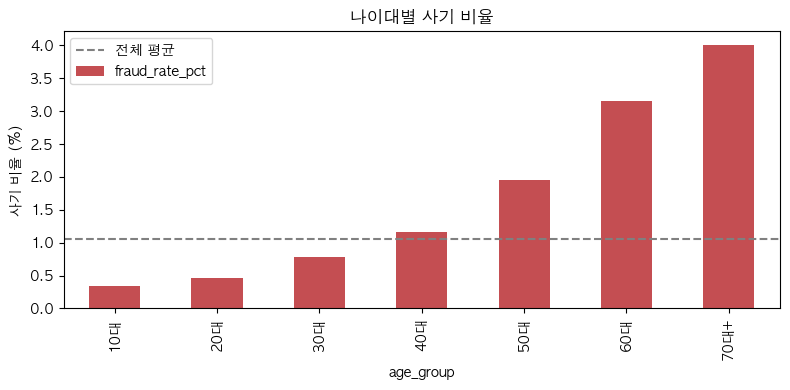

In [8]:
# pd.cut: 숫자 컬럼을 구간(bin)으로 나눠서 새 카테고리 컬럼을 만든다
age_bins = [10, 20, 30, 40, 50, 60, 70, 90]
age_labels = ['10대', '20대', '30대', '40대', '50대', '60대', '70대+']
df['age_group'] = pd.cut(df['customer_age'], bins=age_bins, labels=age_labels, right=False)

age_fraud_rate = df.groupby('age_group', observed=True)['fraud_bool'].agg(['mean', 'count'])
age_fraud_rate['fraud_rate_pct'] = age_fraud_rate['mean'] * 100
print(age_fraud_rate[['fraud_rate_pct', 'count']])

fig, ax = plt.subplots(figsize=(8, 4))
age_fraud_rate['fraud_rate_pct'].plot(kind='bar', ax=ax, color='#C44E52')
ax.axhline(fraud_rate * 100, color='gray', linestyle='--', label='전체 평균')
ax.set_ylabel('사기 비율 (%)')
ax.set_title('나이대별 사기 비율')
ax.legend()
plt.tight_layout()
plt.show()

## 8. 피처 조합으로 보기 — 나이대 × 기기(OS)

지금까지는 "나이대"와 "기기 종류"를 따로따로 봤습니다. 이번엔 두 피처를 동시에 교차해서,
"어떤 나이대가 어떤 기기를 썼을 때 사기율이 특히 높은지" 히트맵으로 확인합니다.
혼자 볼 땐 안 보이던 조합 효과(interaction)가 있는지 찾는 게 목적입니다.

device_os  linux  macintosh  other  windows   x11
age_group                                        
10대         0.17       0.14   0.24     0.74  0.78
20대         0.21       0.74   0.29     1.01  0.43
30대         0.39       1.16   0.44     1.89  0.99
40대         0.54       1.73   0.67     2.45  0.73
50대         0.79       2.26   1.16     3.54  1.99
60대         1.35       3.96   1.74     5.59  1.78
70대+        2.01       6.94   2.15     6.71  2.20


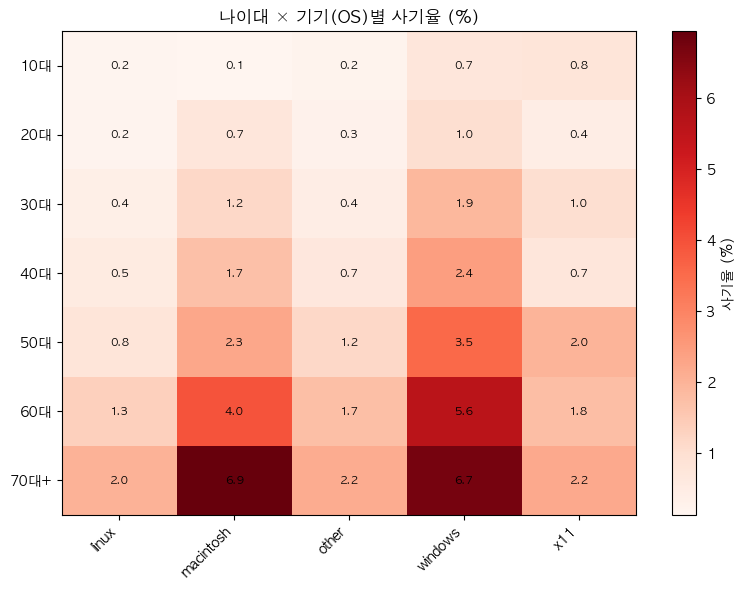

In [9]:
# pivot_table: 행=나이대, 열=기기, 값=사기율 평균 으로 표를 재구성 (엑셀 피벗테이블과 동일한 개념)
pivot = df.pivot_table(
    index='age_group', columns='device_os', values='fraud_bool',
    aggfunc='mean', observed=True
) * 100

print(pivot.round(2))

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap='Reds', aspect='auto')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, rotation=45, ha='right')
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
ax.set_title('나이대 × 기기(OS)별 사기율 (%)')

# 칸마다 실제 숫자를 같이 표시
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        val = pivot.values[i, j]
        if not pd.isna(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=8)

fig.colorbar(im, label='사기율 (%)')
plt.tight_layout()
plt.show()

## 9. 행동 패턴 관점 — 신청이 "몰렸는지" 확인

지금까지는 "이 사람이 누구인지"(나이, 소득, 기기)를 봤습니다. 이번엔 "이 사람이 신청할 때
어떻게 행동했는지"를 봅니다. `velocity_6h`는 "최근 6시간 동안 신청이 몰린 정도"를 나타내는
피처로, 사기 조직이 짧은 시간에 여러 건을 몰아서 신청하는 패턴을 잡기 위해 설계된 피처로 추정됩니다.

값을 5개 구간(quantile, 균등하게 20%씩)으로 나눠서 구간별 사기율을 봅니다.

                    fraud_rate_pct   count
velocity_6h_bucket                        
1(낮음)                     1.327007  180632
2                         1.036367  180631
3                         1.088960  180631
4                         1.011454  180631
5(높음)                     0.851455  180632


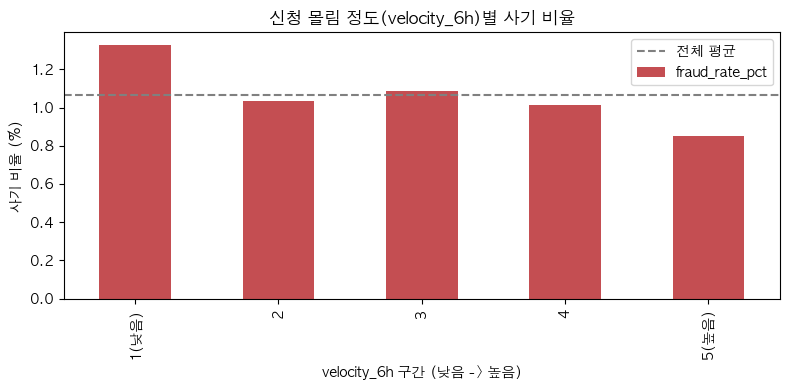

In [10]:
# pd.qcut: pd.cut과 달리 "값 범위"가 아니라 "표본 개수가 똑같게" 구간을 나눔 (5분위 = 20%씩)
df['velocity_6h_bucket'] = pd.qcut(df['velocity_6h'], q=5, labels=['1(낮음)', '2', '3', '4', '5(높음)'])

velocity_fraud = df.groupby('velocity_6h_bucket', observed=True)['fraud_bool'].agg(['mean', 'count'])
velocity_fraud['fraud_rate_pct'] = velocity_fraud['mean'] * 100
print(velocity_fraud[['fraud_rate_pct', 'count']])

fig, ax = plt.subplots(figsize=(8, 4))
velocity_fraud['fraud_rate_pct'].plot(kind='bar', ax=ax, color='#C44E52')
ax.axhline(fraud_rate * 100, color='gray', linestyle='--', label='전체 평균')
ax.set_xlabel('velocity_6h 구간 (낮음 -> 높음)')
ax.set_ylabel('사기 비율 (%)')
ax.set_title('신청 몰림 정도(velocity_6h)별 사기 비율')
ax.legend()
plt.tight_layout()
plt.show()

### velocity_24h, velocity_4w도 같은 패턴인지 확인

`velocity_6h`와 관찰 시간 창만 다른 두 피처(`velocity_24h`=24시간, `velocity_4w`=4주)도
같은 방식(5분위 구간)으로 나눠서, 몰림이 심할수록 사기율이 낮아지는 같은 패턴이 나오는지 비교합니다.

--- velocity_24h ---
velocity_24h_bucket
1(낮음)    1.171
2        0.948
3        1.268
4        1.069
5(높음)    0.859
Name: fraud_bool, dtype: float64



--- velocity_4w ---
velocity_4w_bucket
1(낮음)    1.334
2        0.981
3        1.067
4        0.921
5(높음)    1.012
Name: fraud_bool, dtype: float64



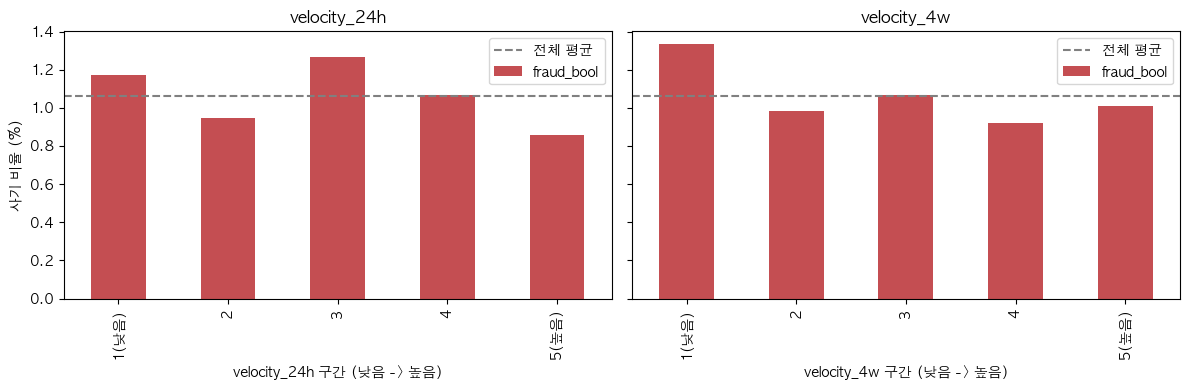

In [11]:
bucket_labels = ['1(낮음)', '2', '3', '4', '5(높음)']

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)

for ax, col in zip(axes, ['velocity_24h', 'velocity_4w']):
    bucket_col = f'{col}_bucket'
    df[bucket_col] = pd.qcut(df[col], q=5, labels=bucket_labels)
    result = df.groupby(bucket_col, observed=True)['fraud_bool'].mean() * 100
    print(f'--- {col} ---')
    print(result.round(3))
    print()

    result.plot(kind='bar', ax=ax, color='#C44E52')
    ax.axhline(fraud_rate * 100, color='gray', linestyle='--', label='전체 평균')
    ax.set_xlabel(f'{col} 구간 (낮음 -> 높음)')
    ax.set_ylabel('사기 비율 (%)')
    ax.set_title(col)
    ax.legend()

plt.tight_layout()
plt.show()

## 정리

- 이 노트북에서 발견한 패턴들을 여기에 직접 적어서, 발표자료(`docs/presentation.md`)의 EDA 섹션에 반영하세요.
- 특정 피처/카테고리의 분포가 사기 그룹에서 뚜렷하게 다르다면, 다음 단계(하이퍼파라미터 튜닝, 피처 엔지니어링)에서 우선적으로 살펴볼 후보가 됩니다.
- 이 노트북은 EDA(탐색) 전용입니다. 실제 파이프라인 로직은 여기서 바꾸지 않고, 항상 `src/preprocess.py` 등 .py 스크립트에만 반영합니다.